In [77]:
import pandas as pd
import starfile
import matplotlib.pyplot as plt

In [79]:
#read the model STAR file as well as the matrix output from the multidimensional scaling in MATLAB
df = starfile.read("./flexions.star")
sc = pd.read_csv('./CSol_TMD.csv',header=None, names=['Scatter1','Scatter2'])

In [80]:
#join the data
df['Scatter1']  = sc['Scatter1']
df['Scatter2']  = sc['Scatter2']

In [81]:
#drop irrelevant models
df = df.drop(45) #acsi
df = df.drop(46) #acdi
df = df.drop(56) #pdan

In [82]:
#construct DFs per each functional state
df_closed = df[df['ModelState'].isin([1])];

df_primed = df[df['ModelState'].isin([2])]
df_open = df[df['ModelState'].isin([3])]
df_pri_act = df[df['ModelId'].isin(['5tan', '5tam', '5taq', '7m6a', '126c', '126d', 'acet', 'acdo', 'acup', 'acsi', 'acdi'])] #forgot 7m6a!!!

df_ry = df[df['ModelId'].isin(['5taw', '5tax', '5tay', '5taz', 'j57c', 'j57d'])]
df_in = df[df['ModelState'].isin([4])]

In [83]:
#drop the repeatetive ones from the pri & open lists to make sure the ranges are adequate.
df_primed = df_primed.drop(15) #5taq
df_primed = df_primed.drop(16) #5tam
df_primed = df_primed.drop(17) #5tan
df_primed = df_primed.drop(27) #7m6a
df_primed = df_primed.drop(42) #acet
df_primed = df_primed.drop(43) #acdo
df_primed = df_primed.drop(44) #acup
df_primed = df_primed.drop(50) #126c
df_primed = df_primed.drop(51) #126d

df_open = df_open.drop(21) #5taw
df_open = df_open.drop(22) #5tax
df_open = df_open.drop(23) #5tay
df_open = df_open.drop(24) #5taz
df_open = df_open.drop(54) #j57c
df_open = df_open.drop(55) #j57d

In [84]:
#reset the indices
df_closed = df_closed.reset_index(drop=True)
df_primed = df_primed.reset_index(drop=True)
df_open = df_open.reset_index(drop=True)
df_pri_act = df_pri_act.reset_index(drop=True)
df_ry = df_ry.reset_index(drop=True)
df_in = df_in.reset_index(drop=True)

In [85]:
#universal label setup

#Apo-state
labels_c = df_closed['ModelId'].to_list()
labels_c[-6] = 'Apo1' #9s5f
labels_c[-5] = 'Apo2' #9s5a
labels_c[-4] = 'Apo3' #9s5c
labels_c[-3] = 'Apo4' #9s5e
labels_c[-2] = 'Apo5' #9s16
labels_c[-1] = 'ACP'  #9s1h

#Activated-state
labels_o = df_open['ModelId'].to_list()
labels_o[-2] = 'ActMix3'  #9s4n
labels_o[-1] = 'ActMix4'  #9s4l

#Primed-state
labels_p = df_primed['ModelId'].to_list()
labels_p[-2] = 'ActCa1'  #9s2s
labels_p[-1] = 'ActCa2'  #9s2r

#Primed-state, ActMix
labels_pa = df_pri_act['ModelId'].to_list()
labels_pa[-5] = 'ActMix5'  #9s5z
labels_pa[-4] = 'ActMix6'  #9s5w
labels_pa[-3] = 'ActMix7'  #9s5y
labels_pa[-2] = 'ActMix1'  #9s3v
labels_pa[-1] = 'ActMix2'  #9s3u

#Locked-state
labels_ry = df_ry['ModelId'].to_list()
labels_ry[-2] = 'Ry1'  #9s55
labels_ry[-1] = 'Ry2'  #9s54

#Inactivated-state
labels_i = df_in['ModelId'].to_list()

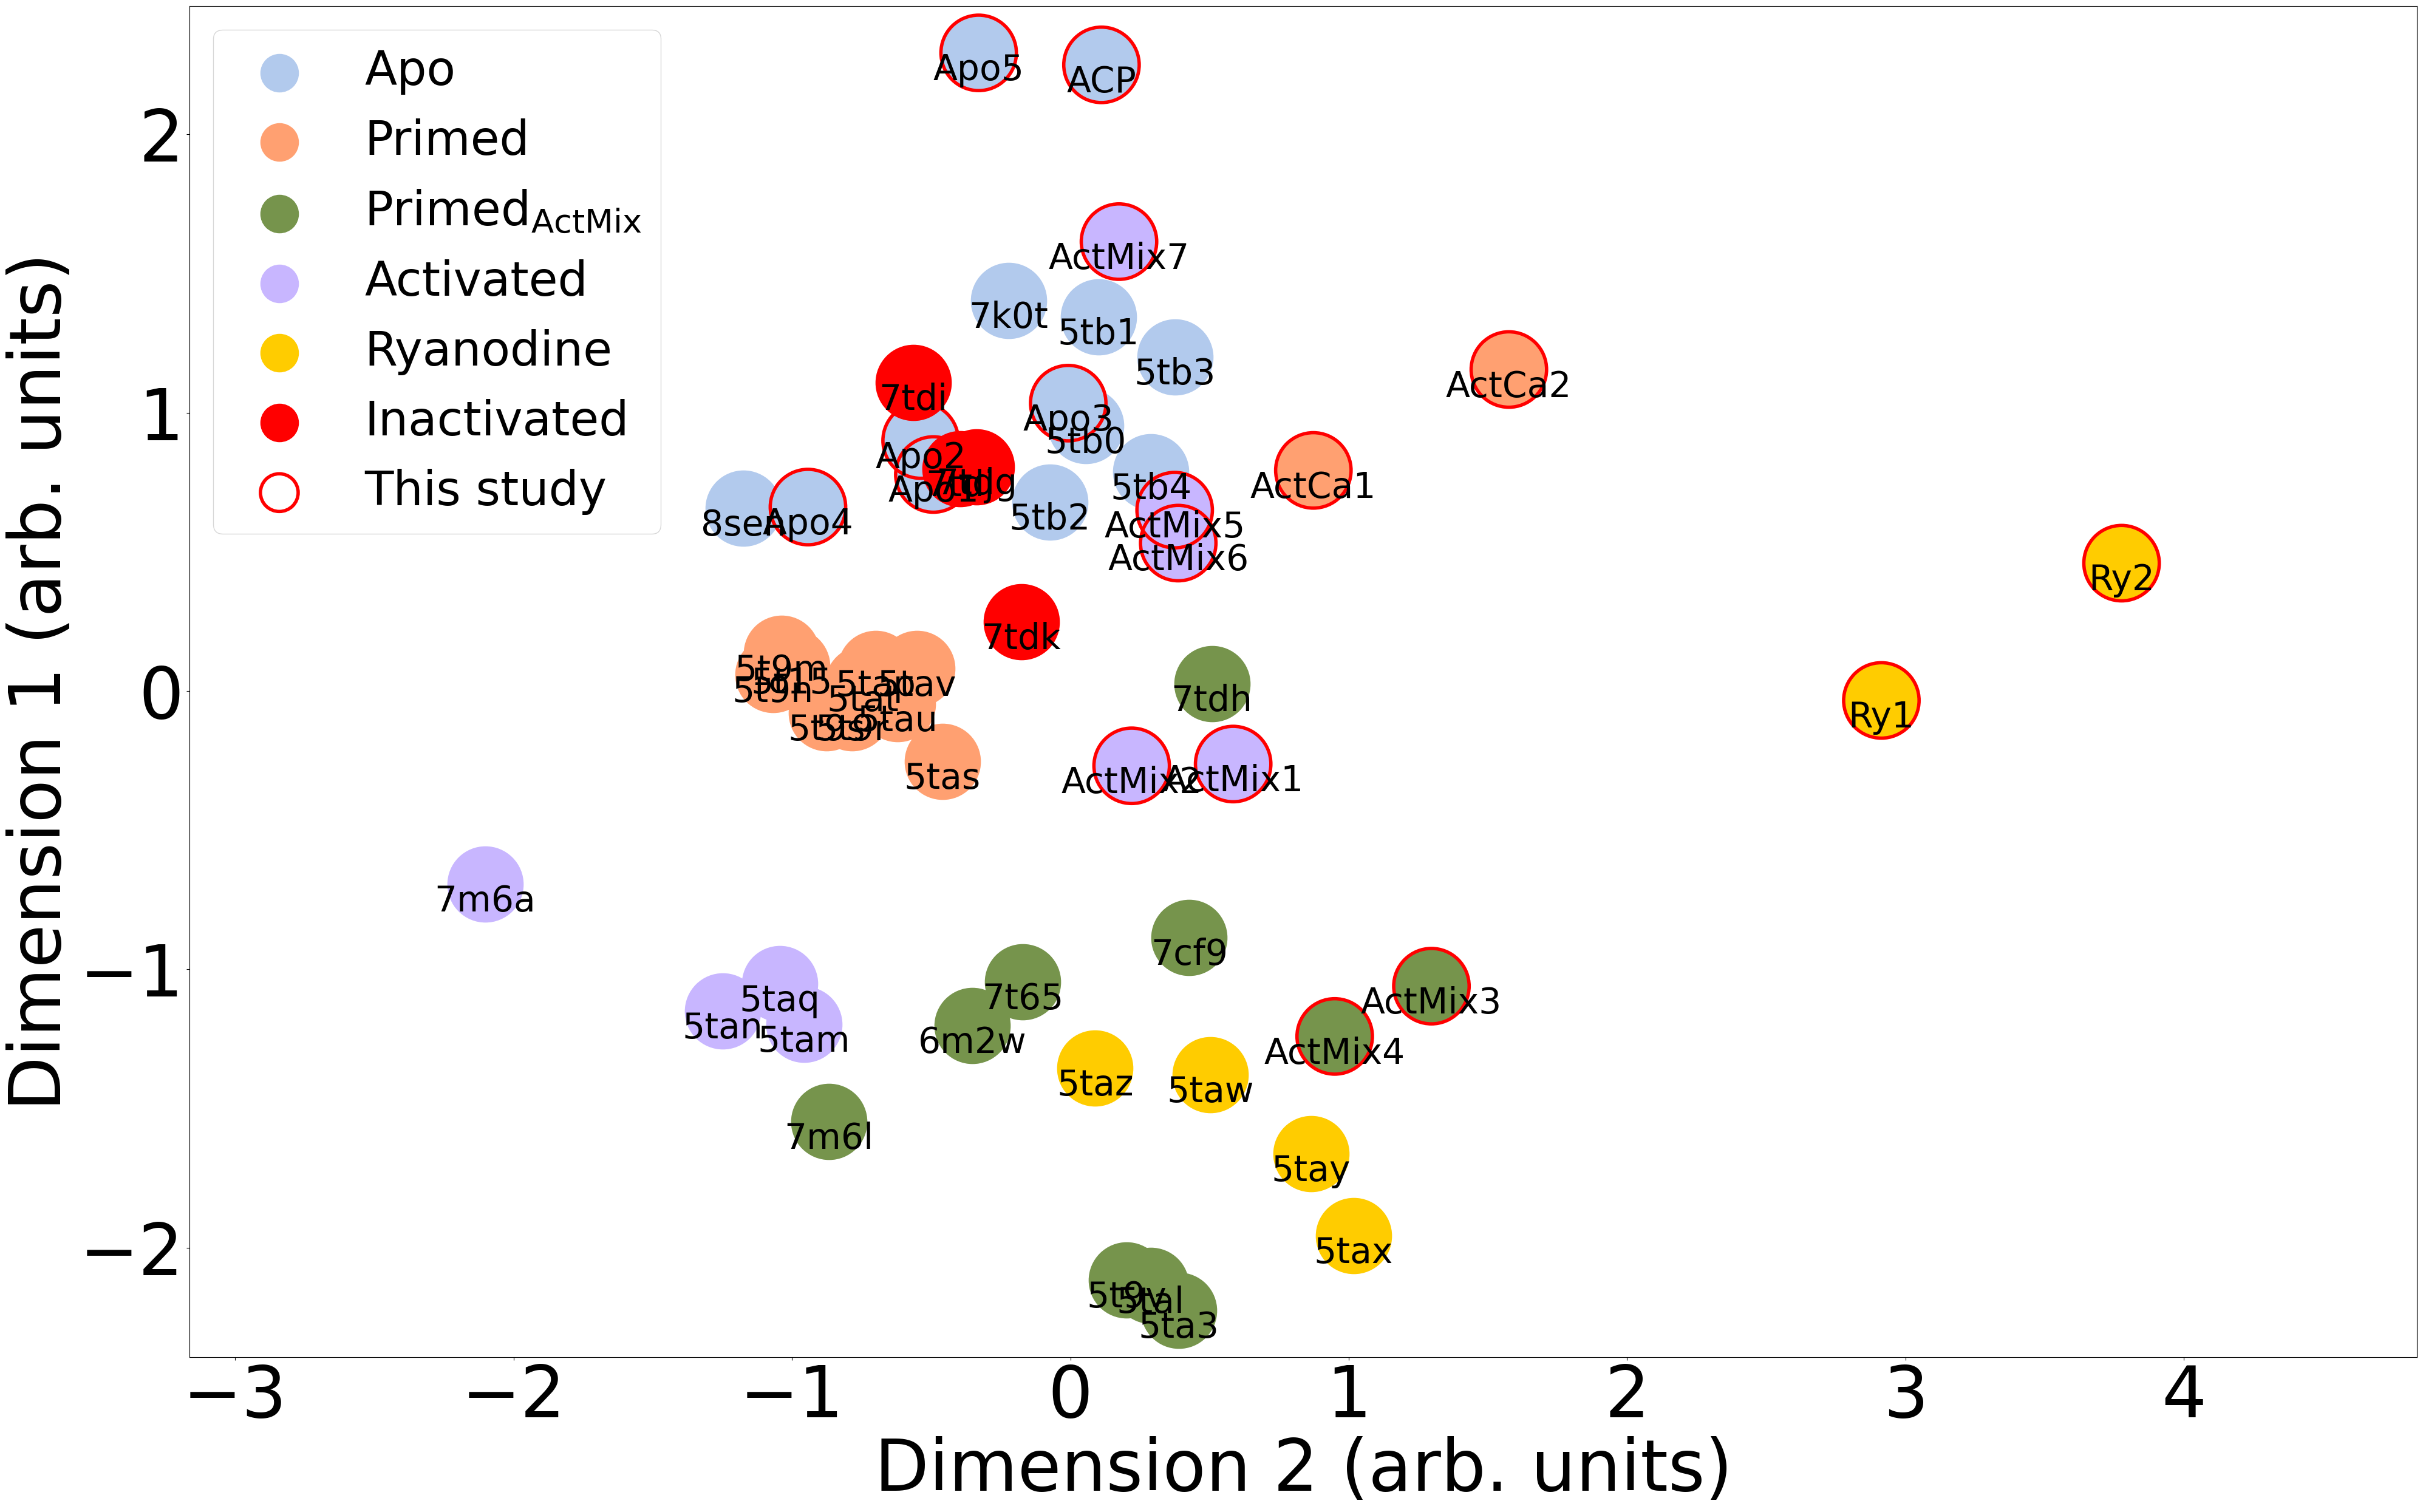

In [95]:
#plot
plt.figure(figsize=(40, 25),dpi=100)
dot_size = 8000
dot_size_my = 8000
font_size = 42*2
font_dots = 42
VA = 'top'
HA = 'center'

tilt_c = df_closed['Scatter1'].to_list()
rot_c = df_closed['Scatter2'].to_list()

tilt_o = df_open['Scatter1'].to_list()
rot_o = df_open['Scatter2'].to_list()

tilt_p = df_primed['Scatter1'].to_list()
rot_p = df_primed['Scatter2'].to_list()

tilt_pa = df_pri_act['Scatter1'].to_list()
rot_pa = df_pri_act['Scatter2'].to_list()

tilt_ry = df_ry['Scatter1'].to_list()
rot_ry = df_ry['Scatter2'].to_list()

tilt_i = df_in['Scatter1'].to_list()
rot_i = df_in['Scatter2'].to_list()

#Purified channel data
plt.scatter(rot_c,tilt_c,color='#b2caed',s=dot_size)
for i,label in enumerate(labels_c):
    plt.text(rot_c[i],tilt_c[i],label,fontsize=font_dots, ha=HA, va=VA)
    
plt.scatter(rot_p,tilt_p,color='#ffa071',s=dot_size)
for i,label in enumerate(labels_p):
    plt.text(rot_p[i],tilt_p[i],label,fontsize=font_dots, ha=HA, va=VA)
    
plt.scatter(rot_o,tilt_o,color='#76944c',s=dot_size)
for i,label in enumerate(labels_o):
    plt.text(rot_o[i],tilt_o[i],label,fontsize=font_dots, ha=HA, va=VA)

plt.scatter(rot_pa,tilt_pa,color='#c8b6ff',s=dot_size)
for i,label in enumerate(labels_pa):
    plt.text(rot_pa[i],tilt_pa[i],label,fontsize=font_dots, ha=HA, va=VA)
    
plt.scatter(rot_ry,tilt_ry,color='#ffcc00',s=dot_size)
for i,label in enumerate(labels_ry):
    plt.text(rot_ry[i],tilt_ry[i],label,fontsize=font_dots, ha=HA, va=VA)

plt.scatter(rot_i,tilt_i,color='red',s=dot_size)
for i,label in enumerate(labels_i):
    plt.text(rot_i[i],tilt_i[i],label,fontsize=font_dots, ha=HA, va=VA)

#SR channel data
plt.scatter(rot_c[-6:],tilt_c[-6:],  facecolors='none', s=dot_size_my,alpha=1,linewidths=4,edgecolors='r')
plt.scatter(rot_p[-2:],tilt_p[-2:],  facecolors='none', s=dot_size_my,alpha=1,linewidths=4,edgecolors='r')
plt.scatter(rot_pa[-5:],tilt_pa[-5:],facecolors='none', s=dot_size_my,alpha=1,linewidths=4,edgecolors='r')
plt.scatter(rot_o[-2:],tilt_o[-2:],  facecolors='none', s=dot_size_my,alpha=1,linewidths=4,edgecolors='r')
plt.scatter(rot_ry[-2:],tilt_ry[-2:],facecolors='none', s=dot_size_my,alpha=1,linewidths=4,edgecolors='r')

plt.xlabel('Dimension 2 (arb. units)',fontsize=font_size)
plt.ylabel('Dimension 1 (arb. units)',fontsize=font_size,rotation=90)
plt.yticks(rotation=0,fontsize=font_size)
plt.xticks(rotation=0,fontsize=font_size)

plt.legend(['Apo','Primed', r'$\mathrm{Primed}_{\mathrm{ActMix}}$', 'Activated', 'Ryanodine', 'Inactivated', 'This study'], fontsize=font_size/1.5,loc="upper left",markerscale=0.5)
plt.axis('equal')
plt.tight_layout()

plt.savefig("./CSol_TMD_example.svg",transparent=1,dpi=300,format="svg")
plt.savefig("./CSol_TMD_example.png",transparent=1,dpi=300,format="png")
plt.savefig("./CSol_TMD_example.pdf",transparent=1,dpi=300,format="pdf")

plt.show()